### NARX data interpretation

In [7]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

lag = 5
out_dim = 1
units = 32
n_epochs = 150
bs = 64
tol = 5
no_improve = 0

data = np.load(
    "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files/training-val-test-data.npz"
)
y_raw = data["th"]
u_raw = data["u"]


def build_regressor_matrix(u, y, p):
    # stack lagged inputs and outputs into rows
    # each row: [u(k-p)...u(k-1), y(k-p)...y(k-1)] -> y(k)
    phi, targets = [], []
    for k in range(p, len(y)):
        phi.append(np.concatenate([u[k-p:k], y[k-p:k]]))
        targets.append(y[k])
    return np.array(phi), np.array(targets)

### Normalize data

In [8]:
phi, targets = build_regressor_matrix(u_raw, y_raw, lag)

phi_tv, phi_test, t_tv, t_test = train_test_split(
    phi, targets, test_size=0.3, random_state=24, shuffle=False
)
phi_train, phi_val, t_train, t_val = train_test_split(
    phi_tv, t_tv, test_size=0.35, random_state=24, shuffle=True
)

x_mu  = phi_train.mean(axis=0)
x_sig = phi_train.std(axis=0)
y_mu  = t_train.mean()
y_sig = t_train.std()

phi_train = (phi_train - x_mu) / x_sig
phi_val   = (phi_val - x_mu) / x_sig
phi_test  = (phi_test - x_mu) / x_sig
t_train   = (t_train - y_mu) / y_sig
t_val     = (t_val - y_mu) / y_sig
t_test    = (t_test - y_mu) / y_sig

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
phi_train, phi_val, phi_test = to_t(phi_train), to_t(phi_val), to_t(phi_test)
t_train,   t_val, t_test   = to_t(t_train), to_t(t_val), to_t(t_test)

input_size = phi_train.shape[1]

### simple neural network structure

In [9]:
class MLP(nn.Module):
    def __init__(self, n_in, n_out, n_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden).float()
        self.fc2 = nn.Linear(n_hidden, n_hidden).float()
        self.fc3 = nn.Linear(n_hidden, n_out).float()

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return self.fc3(x)[:, 0]

model = MLP(input_size, out_dim, units)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn  = nn.MSELoss()

### training loop for the simple NN model. Using the normalized NARX data

In [10]:
idx = np.arange(len(phi_train), dtype=int)
best_val   = float("inf")
best_state = None
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    np.random.shuffle(idx)

    model.train()
    for i in range(0, len(phi_train), bs):
        batch = idx[i:i+bs]
        pred = model(phi_train[batch])
        loss = loss_fn(pred, t_train[batch])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        model.eval()
        v_rmse = loss_fn(model(phi_val),   t_val).sqrt()
        t_rmse = loss_fn(model(phi_train), t_train).sqrt()

    print(f"epoch {epoch}  train {t_rmse:.4f}  val {v_rmse:.4f}")

    if v_rmse < best_val:
        best_val = v_rmse
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1

    if no_improve >= tol:
        print(f"early stop at epoch {epoch}, best val {best_val:.4f}")
        break

    train_hist.append(t_rmse.item())
    val_hist.append(v_rmse.item())

model.load_state_dict(best_state)

epoch 0  train 0.3178  val 0.3246
epoch 1  train 0.1371  val 0.1430
epoch 2  train 0.1235  val 0.1288
epoch 3  train 0.1115  val 0.1164
epoch 4  train 0.1075  val 0.1118
epoch 5  train 0.0939  val 0.0982
epoch 6  train 0.0869  val 0.0909
epoch 7  train 0.0826  val 0.0862
epoch 8  train 0.0772  val 0.0807
epoch 9  train 0.0737  val 0.0768
epoch 10  train 0.0724  val 0.0754
epoch 11  train 0.0681  val 0.0707
epoch 12  train 0.0622  val 0.0648
epoch 13  train 0.0603  val 0.0629
epoch 14  train 0.0630  val 0.0653
epoch 15  train 0.0546  val 0.0569
epoch 16  train 0.0526  val 0.0550
epoch 17  train 0.0513  val 0.0533
epoch 18  train 0.0489  val 0.0510
epoch 19  train 0.0492  val 0.0512
epoch 20  train 0.0464  val 0.0483
epoch 21  train 0.0421  val 0.0440
epoch 22  train 0.0444  val 0.0460
epoch 23  train 0.0488  val 0.0501
epoch 24  train 0.0408  val 0.0423
epoch 25  train 0.0376  val 0.0393
epoch 26  train 0.0368  val 0.0382
epoch 27  train 0.0376  val 0.0390
epoch 28  train 0.0324  val 0.

<All keys matched successfully>

### Evuation of the model using test data split

RMS:  0.0068 rad  /  0.3882 deg
NRMS: 1.34%


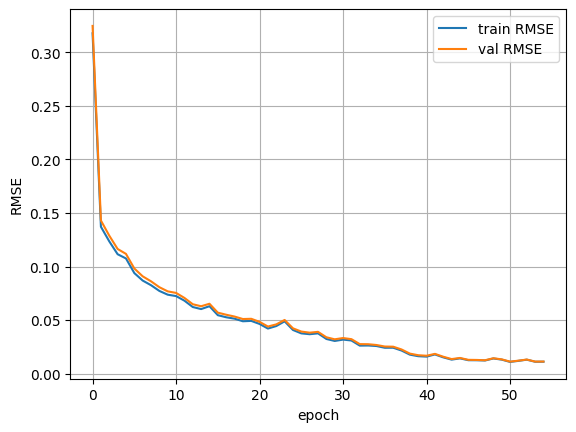

In [11]:
model.eval()
with torch.no_grad():
    pred_norm = model(phi_test).numpy()

pred_real = pred_norm * y_sig + y_mu
true_real = t_test.numpy() * y_sig + y_mu

rms = np.mean((pred_real - true_real)**2)**0.5
print(f"RMS:  {rms:.4f} rad  /  {rms/(2*np.pi)*360:.4f} deg")
print(f"NRMS: {rms/np.std(true_real)*100:.2f}%")

plt.plot(train_hist, label="train RMSE")
plt.plot(val_hist, label="val RMSE")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(); plt.show()